In [12]:

#TASK 1-- Download a sample sales dataset (for example, from Kaggle or use a small CSV you create) with columns like product, category, date, and sales amount. Load it into a Pandas DataFrame and display the first 5 rows to verify the data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



data = {
    "product": [
        "Laptop", "T-Shirt", "Rice", "Mobile", "Jeans",
        "Oil", "Headphones", "Shoes", "Sugar", "Tablet",
        "Keyboard", "Jacket", "Flour", "Smartwatch", "Monitor"
    ],
    
    "category": [
        "Electronics", "Clothing", "Groceries", "Electronics", "Clothing",
        "Groceries", "Electronics", "Clothing", "Groceries", "Electronics",
        "Electronics", "Clothing", "Groceries", "Electronics", "Electronics"
    ],
    
    "date": [
        "2025-01-15", "2025-01-20", "2025-02-10", "2025-02-18", "2025-03-05",
        "2025-03-15", "2025-04-10", "2025-05-12", "2025-06-08", "2025-07-15",
        "2025-08-10", "2025-09-05", "2025-10-12", "2025-11-18", "2025-12-20"
    ],
    
    "sales_amount": [
        55000, 1800, 2500, 35000, 3200,
        2200, 4500, 4000, 1800, 28000,
        2500, 5500, 2000, 12000, 18000
    ]
}

df = pd.DataFrame(data)


df["date"] = pd.to_datetime(df["date"])


df.to_csv("sales_dataset.csv", index=False)


print(df.head())

   product     category       date  sales_amount
0   Laptop  Electronics 2025-01-15         55000
1  T-Shirt     Clothing 2025-01-20          1800
2     Rice    Groceries 2025-02-10          2500
3   Mobile  Electronics 2025-02-18         35000
4    Jeans     Clothing 2025-03-05          3200


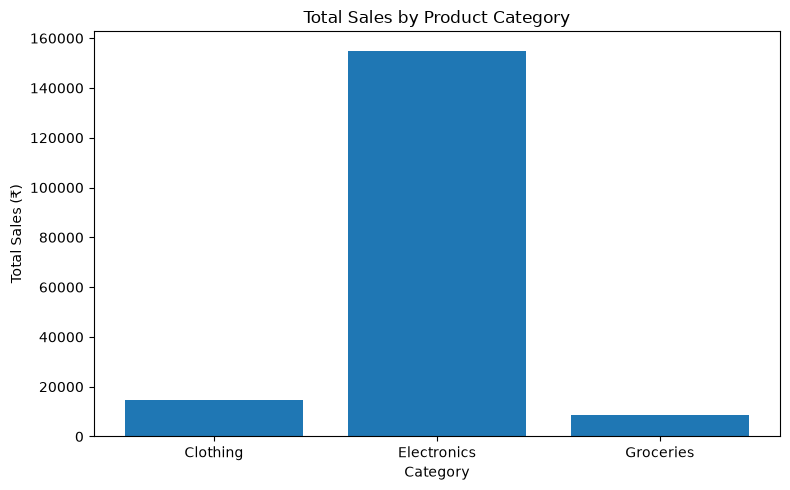

In [13]:
#TASK 2-- Using Matplotlib, create a bar chart that shows total sales for each product category (like 'Electronics', 'Clothing', 'Groceries'), similar to how Flipkart or Myntra might track category performance.



category_sales = df.groupby("category")["sales_amount"].sum()

plt.figure(figsize=(8, 5))

plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales (₹)")

plt.tight_layout()
plt.show()

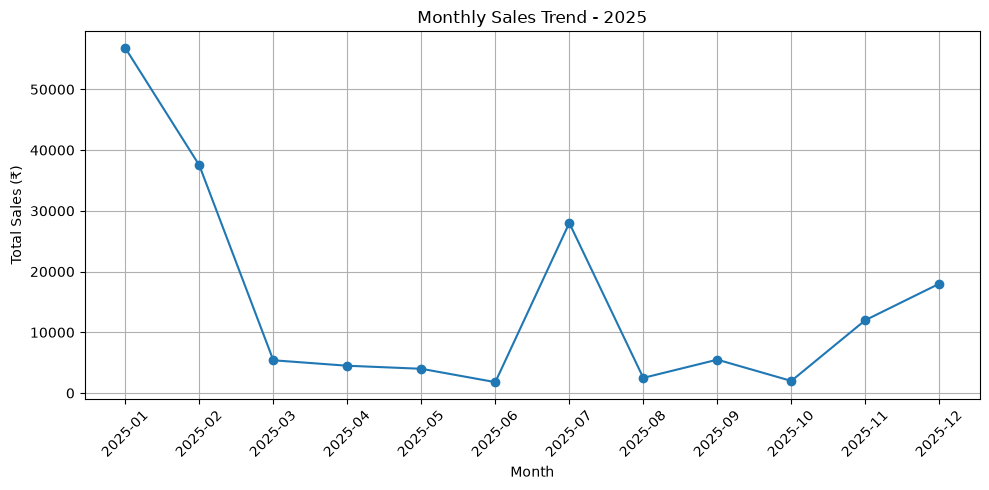

In [14]:
#TASK 3-- Plot a line chart to visualize monthly sales trends over a year, using the date column to group sales by month. Add a title and axis labels to make the chart presentation-ready.

monthly_sales = df.groupby(
    df["date"].dt.to_period("M")
)["sales_amount"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend - 2025")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")

plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()

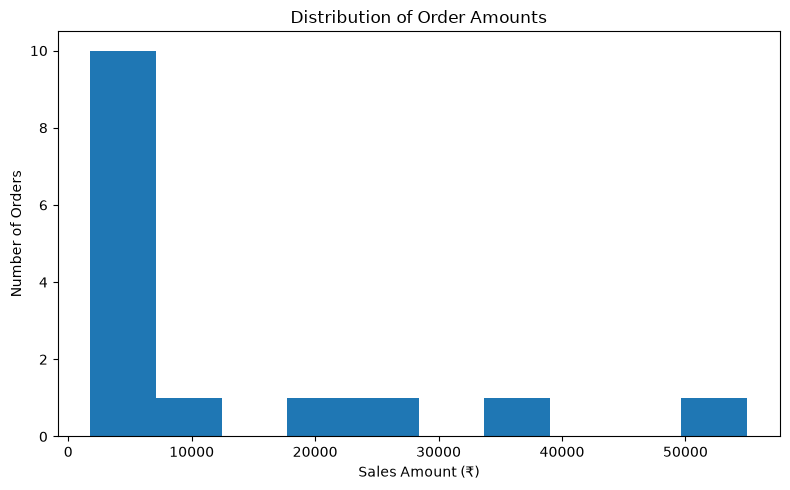

In [15]:
#TASK 4-- Create a histogram to show the distribution of order amounts (sales values), highlighting how many small vs. large purchases happen — like analyzing order size patterns on Zomato or Swiggy.<br><br><em><strong>Hint:</strong> Use plt.hist() and set bins to 10 for a clear distribution.</em>

plt.figure(figsize=(8, 5))

plt.hist(
    df["sales_amount"],
    bins=10
)

plt.title("Distribution of Order Amounts")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

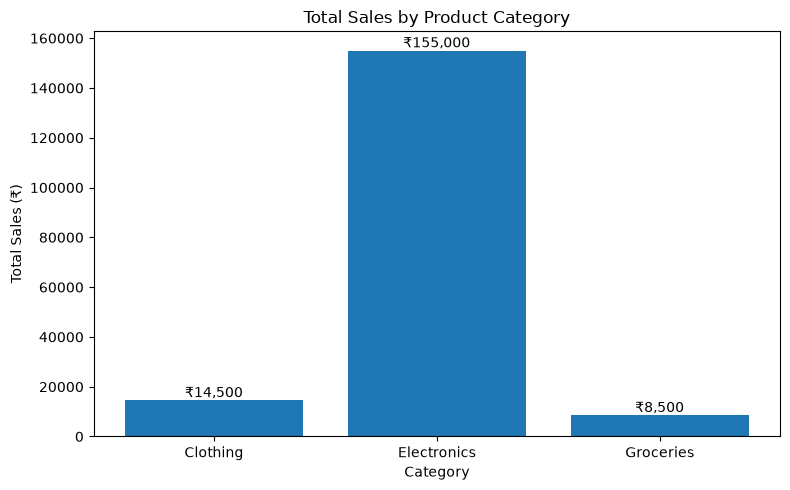

In [16]:
#TASK 5-- Add value annotations to your category bar chart to display the exact sales amount above each bar, then export the chart as a PNG image file named 'category_sales_kpi.png'.

import matplotlib.pyplot as plt

category_sales = df.groupby("category")["sales_amount"].sum()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales (₹)")

# Add value annotations
for bar in bars:
    value = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"₹{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Save as PNG
plt.savefig(
    "category_sales_kpi.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()